In [1]:
# --- Block 1: Imports + paths (run once) ---
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd

DATA_DIR = Path("../Data")
OUT_DIR  = DATA_DIR  # (R saved into the same folder; change if you want)

ECObank_FP = DATA_DIR / "ecobank_full.csv"
VT_FP      = DATA_DIR / "ecobank_cultured.csv"
FRED_FP    = DATA_DIR / "FRED_4_20250921_filteredforMicrobeNet_AMF_FineRootsLess2mm.csv"

assert ECObank_FP.exists(), ECObank_FP
assert VT_FP.exists(), VT_FP
assert FRED_FP.exists(), FRED_FP

In [2]:
# --- Block 2: Load data (matches R read.csv + separators) ---
ecobank = pd.read_csv(ECObank_FP, sep=";")
vt      = pd.read_csv(VT_FP, sep=";")

# --- Block: Load FRED properly (skip first row, use second row as header) ---

# Read raw file without assigning header
fred_raw = pd.read_csv(FRED_FP, header=None)

# Use the SECOND row (index 1) as column names
fred_raw.columns = fred_raw.iloc[1].astype(str)

# Drop the first two rows (original row 1 + header row)
fred = fred_raw.iloc[2:].copy()

# Reset index
fred.reset_index(drop=True, inplace=True)

print("FRED shape:", fred.shape)
print("First columns:", fred.columns[:10])

FRED shape: (6276, 63)
First columns: Index(['Version_FRED version number', 'Notes_Row ID',
       'Abbreviated article citation', 'Data source_Citation',
       'Data source_DOI', 'Data set_Citation', 'Data set_DOI', 'Notes_Site ID',
       'Data_Raw or unpublished', 'Data_Duplicate data'],
      dtype='object', name=1)


/tmp/ipykernel_90636/4082845866.py:3: DtypeWarning: Columns (1,2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  vt      = pd.read_csv(VT_FP, sep=";")


In [3]:
# --- Block 3: Sort + merge + filter roots (matches R order/merge/subset) ---
ecobank = ecobank.sort_values("sample")
vt      = vt.sort_values("sample")

roots = ecobank.merge(vt, on="sample", how="inner")

# R: roots <- subset(roots, isRoot == TRUE)
# In some exports this may be True/False, 0/1, or "TRUE"/"FALSE".
if roots["isRoot"].dtype == object:
    is_root = roots["isRoot"].astype(str).str.upper().isin(["TRUE", "T", "1", "YES"])
else:
    is_root = roots["isRoot"].astype(bool)

roots = roots.loc[is_root].copy()

print("roots:", roots.shape)

roots: (2705, 460)


In [20]:
# --- Block: Resolve roots/ecobank names via direct GBIF API (no pygbif dependency) ---

import time
from pathlib import Path
from urllib.parse import urlencode

import numpy as np
import pandas as pd
import requests

# Unique species names from roots/ecobank
names = (
    roots["plant_species"]
    .dropna()
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

GBIF_MATCH_URL = "https://api.gbif.org/v1/species/match"

session = requests.Session()
session.headers.update({"User-Agent": "pal-name-resolution/1.0 (contact: you)"})

def gbif_match_one(name: str, kingdom: str = "Plantae", strict: bool = False, timeout: int = 30):
    params = {
        "name": name,
        "kingdom": kingdom,
        "strict": "true" if strict else "false",
    }
    try:
        r = session.get(GBIF_MATCH_URL, params=params, timeout=timeout)
        r.raise_for_status()
        res = r.json()
        # Standardize into a stable schema
        return {
            "query": name,
            "matchType": res.get("matchType"),
            "confidence": res.get("confidence"),
            "rank": res.get("rank"),
            "status": res.get("status"),
            "note": res.get("note"),
            "usageKey": res.get("usageKey"),
            "acceptedUsageKey": res.get("acceptedUsageKey"),
            "scientificName": res.get("scientificName"),
            "canonicalName": res.get("canonicalName"),
        }
    except Exception as e:
        return {"query": name, "error": str(e)}

rows = []
for i, nm in enumerate(names, 1):
    rows.append(gbif_match_one(nm, strict=False))
    # mild rate limiting
    if i % 50 == 0:
        time.sleep(1.0)

df_gbif = pd.DataFrame(rows)

print("Results:", df_gbif.shape)
print("\nErrors:", int(df_gbif.get("error", pd.Series([None]*len(df_gbif))).notna().sum()), "/", len(df_gbif))
if "matchType" in df_gbif.columns:
    print("\nmatchType counts:")
    print(df_gbif["matchType"].value_counts(dropna=False).head(20).to_string())

# Resolved name (accepted-ish)
df_gbif["resolved_name"] = (
    df_gbif.get("canonicalName")
    .fillna(df_gbif.get("scientificName"))
    .fillna(df_gbif["query"])
)

out_fp = Path("../Data/roots_names_gbif_resolved.csv")
df_gbif.to_csv(out_fp, index=False)
print("\nSaved:", out_fp)

Results: (462, 10)

Errors: 0 / 462

matchType counts:
matchType
EXACT         425
HIGHERRANK     32
FUZZY           5

Saved: ../Data/roots_names_gbif_resolved.csv


In [21]:
# --- Block: compute overlap after GBIF resolution ---

roots_resolved_set = set(df_gbif["resolved_name"].dropna().unique())
fred_set = set(fred["species"].dropna().astype(str).str.strip().unique())

print("Overlap after GBIF resolution:", len(roots_resolved_set & fred_set))

Overlap after GBIF resolution: 38


In [22]:
# --- Block: Diagnose why overlap stayed 38 (canonicalize BOTH sides + show near-misses) ---

import re
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# Canonicalization (same on both datasets)
# ----------------------------
QUALIFIERS = {
    "sp", "sp.", "spp", "spp.", "indet", "indet.", "cf", "cf.", "aff", "aff.",
    "nr", "nr.", "unidentified", "unknown"
}
INFRA = {"subsp", "subsp.", "ssp", "ssp.", "var", "var.", "forma", "forma.", "f", "f."}

def canonical_binomial(name: str):
    """
    Canonicalize to 'Genus epithet' where epithet is the first plausible species epithet.
    Drops authorship (parentheses), infra ranks, qualifiers, punctuation.
    """
    if pd.isna(name):
        return np.nan

    s = str(name).strip()
    if not s:
        return np.nan

    # remove parenthetical authorship
    s = re.sub(r"\([^)]*\)", " ", s)
    # normalize hybrid sign, punctuation
    s = s.replace("×", "x")
    s = re.sub(r"[^\w\s-]", " ", s)   # keep hyphens
    s = re.sub(r"\s+", " ", s).strip()

    parts = s.split(" ")
    if len(parts) < 2:
        return np.nan

    genus = parts[0]

    epithet = None
    for tok in parts[1:]:
        t = tok.lower().strip()
        if t in QUALIFIERS or t in INFRA:
            continue
        if len(t) == 1:
            continue
        if re.fullmatch(r"[a-z]+(-[a-z]+)?", t) is None:
            continue
        epithet = t
        break

    if epithet is None:
        return np.nan

    return f"{genus} {epithet}"

# ----------------------------
# Load GBIF-resolved names
# ----------------------------
gbif_fp = Path("../Data/roots_names_gbif_resolved.csv")
assert gbif_fp.exists(), gbif_fp
df_gbif = pd.read_csv(gbif_fp)

# Roots keys from GBIF resolved_name
roots_key = (
    df_gbif["resolved_name"]
    .dropna()
    .astype(str)
    .map(canonical_binomial)
    .dropna()
    .drop_duplicates()
)

# FRED keys from your current fred["species"] (whatever you built previously)
fred_key = (
    fred["species"]
    .dropna()
    .astype(str)
    .map(canonical_binomial)
    .dropna()
    .drop_duplicates()
)

roots_key_set = set(roots_key)
fred_key_set  = set(fred_key)

print("Unique canonical roots keys:", len(roots_key_set))
print("Unique canonical FRED keys: ", len(fred_key_set))
print("Canonical overlap:", len(roots_key_set & fred_key_set))

# ----------------------------
# If overlap is still low: show genus overlap + a few near-miss examples (diagnostic)
# ----------------------------
roots_genera = set([x.split(" ", 1)[0] for x in roots_key_set])
fred_genera  = set([x.split(" ", 1)[0] for x in fred_key_set])

print("\nGenus overlap:", len(roots_genera & fred_genera))
print("Roots-only genera:", len(roots_genera - fred_genera))
print("FRED-only genera: ", len(fred_genera - roots_genera))

# Build per-genus lists for near-miss inspection
from collections import defaultdict
fred_by_genus = defaultdict(list)
for x in fred_key_set:
    g = x.split(" ", 1)[0]
    fred_by_genus[g].append(x)

# Use difflib as a lightweight near-miss finder
import difflib

roots_only = sorted(roots_key_set - fred_key_set)

near_misses = []
for q in roots_only:
    g = q.split(" ", 1)[0]
    choices = fred_by_genus.get(g, [])
    if not choices:
        continue
    m = difflib.get_close_matches(q, choices, n=1, cutoff=0.0)
    if m:
        score = difflib.SequenceMatcher(None, q, m[0]).ratio() * 100.0
        if score >= 90:  # high similarity suggests spelling variant
            near_misses.append((q, m[0], score))

near_misses = sorted(near_misses, key=lambda t: -t[2])

print("\nHigh-similarity within-genus near-misses (top 25):")
for a, b, sc in near_misses[:25]:
    print(f"{a:30s}  ~  {b:30s}  score={sc:5.1f}")

Unique canonical roots keys: 429
Unique canonical FRED keys:  923
Canonical overlap: 40

Genus overlap: 106
Roots-only genera: 186
FRED-only genera:  418

High-similarity within-genus near-misses (top 25):
Deschampsia caespitosa          ~  Deschampsia cespitosa           score= 97.7


In [23]:
# --- Block: show candidate genus/species columns in FRED4 ---
sorted([c for c in fred.columns if ("genus" in c.lower() or "species" in c.lower()) and "taxonomy" in c.lower()])

['Plant Taxonomy_Accepted species_WFO',
 'Plant Taxonomy_Accepted subspecies_WFO',
 'Plant taxonomy_Accepted genus_WFO',
 'Plant taxonomy_Genus_Data Source',
 'Plant taxonomy_Species_Data source',
 'Plant taxonomy_Subspecies_Data source']

In [24]:
# --- Block: list top missing genera (roots-only and FRED-only) ---

roots_genera = sorted(set([x.split(" ", 1)[0] for x in roots_key_set]))
fred_genera  = sorted(set([x.split(" ", 1)[0] for x in fred_key_set]))

roots_only_genera = sorted(set(roots_genera) - set(fred_genera))
fred_only_genera  = sorted(set(fred_genera) - set(roots_genera))

print("Roots-only genera (first 50):")
print(roots_only_genera[:50])

print("\nFRED-only genera (first 50):")
print(fred_only_genera[:50])

Roots-only genera (first 50):
['Acinos', 'Aconogonon', 'Actaea', 'Actinotus', 'Aegopodium', 'Ageratum', 'Ainsliaea', 'Ajania', 'Ajuga', 'Alphitonia', 'Amphicarpaea', 'Anaphalis', 'Aquilegia', 'Arabis', 'Araucaria', 'Arum', 'Aspalathus', 'Asphodelus', 'Asplenium', 'Asteriscus', 'Azorella', 'Baccharis', 'Bactris', 'Bassia', 'Begonia', 'Biebersteinia', 'Bistorta', 'Blysmus', 'Borreria', 'Briza', 'Bupleurum', 'Cacalia', 'Caragana', 'Centaurium', 'Chaerophyllum', 'Chamaecostus', 'Chondrosum', 'Citrullus', 'Cliffortia', 'Commelina', 'Conioselinum', 'Convallaria', 'Conyza', 'Cremanthodium', 'Crotalaria', 'Cullen', 'Cymbopogon', 'Cynodon', 'Delphinium', 'Desmodium']

FRED-only genera (first 50):
['Abies', 'Acacia', 'Achnatherum', 'Acronychia', 'Adesmia', 'Adinandra', 'Agathis', 'Aglaia', 'Agoseris', 'Alchemilla', 'Aleurites', 'Allophylus', 'Alnus', 'Alseis', 'Alseodaphne', 'Alternanthera', 'Altingia', 'Ambrosia', 'Amelanchier', 'Amorpha', 'Amphibromus', 'Andromeda', 'Angelica', 'Aniba', 'Apody

In [25]:
# what file-level metadata / filtering hints are in the columns?
[c for c in fred.columns if "filter" in c.lower() or "microbenet" in c.lower() or "subset" in c.lower() or "amf" in c.lower()]

[]

In [26]:
# compare genus overlap between FRED3 and FRED4

fred3 = pd.read_csv("../Data/FRED3_fineRoots.csv", skiprows=1)

fred3["species"] = (
    fred3["Plant taxonomy_Accepted genus_TPL"].astype(str).str.strip() + " " +
    fred3["Plant Taxonomy_Accepted species_TPL"].astype(str).str.strip()
)

fred3_key = set(fred3["species"].map(canonical_binomial).dropna().unique())

print("FRED3 canonical overlap with roots:", len(fred3_key & roots_key_set))
print("FRED4 canonical overlap with roots:", len(fred_key_set & roots_key_set))

FRED3 canonical overlap with roots: 89
FRED4 canonical overlap with roots: 40


In [27]:
print("Roots genera:", len(roots_genera))
print("FRED3 genera:", len(set([x.split(" ",1)[0] for x in fred3_key])))
print("FRED4 genera:", len(set([x.split(" ",1)[0] for x in fred_key_set])))

Roots genera: 292
FRED3 genera: 136
FRED4 genera: 524


In [35]:
# --- Block: Load FRED4 with correct header row (row 2 contains the real column headers) ---

from pathlib import Path
import pandas as pd

FRED4_FP = Path("../Data/FRED_4_20250921_filteredforMicrobeNet_AMF_FineRootsLess2mm.csv")
assert FRED4_FP.exists(), FRED4_FP

# Row 0: F-codes
# Row 1: human-readable column headers (what we want)
# Row 2+: definitions / notes + data
fred4 = pd.read_csv(FRED4_FP, header=1)

print("fred4 shape:", fred4.shape)
print("First 20 columns:")
for c in fred4.columns[:20]:
    print("  -", repr(c))

# sanity check: these should now exist
needed = [
    "Plant taxonomy_Accepted genus_WFO",
    "Plant Taxonomy_Accepted species_WFO",
]
print("\nMissing needed columns:", [c for c in needed if c not in fred4.columns])

fred4 shape: (6276, 63)
First 20 columns:
  - 'Version_FRED version number'
  - 'Notes_Row ID'
  - 'Abbreviated article citation'
  - 'Data source_Citation'
  - 'Data source_DOI'
  - 'Data set_Citation'
  - 'Data set_DOI'
  - 'Notes_Site ID'
  - 'Data_Raw or unpublished'
  - 'Data_Duplicate data'
  - 'Plant taxonomy_Accepted group_WFO'
  - 'Plant taxonomy_Accepted order_WFO'
  - 'Plant taxonomy_Accepted family_WFO'
  - 'Plant taxonomy_Accepted genus_WFO'
  - 'Plant Taxonomy_Accepted species_WFO'
  - 'Plant Taxonomy_Accepted subspecies_WFO'
  - 'Plant taxonomy_Family_Data source'
  - 'Plant taxonomy_Genus_Data Source'
  - 'Plant taxonomy_Species_Data source'
  - 'Plant taxonomy_Subspecies_Data source'

Missing needed columns: []


In [36]:
# --- Block: recompute FRED4 species + genus overlap (after proper loading) ---

import re
import pandas as pd

QUALIFIERS = {"sp","sp.","spp","spp.","indet","indet.","cf","cf.","aff","aff.","nr","nr.","unknown","unidentified"}
INFRA = {"subsp","subsp.","ssp","ssp.","var","var.","forma","forma.","f","f."}

def canonical_binomial(name: str):
    if pd.isna(name):
        return None
    s = str(name).strip()
    if not s:
        return None
    s = re.sub(r"\([^)]*\)", " ", s)
    s = s.replace("×", "x")
    s = re.sub(r"[^\w\s-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    parts = s.split(" ")
    if len(parts) < 2:
        return None
    genus = parts[0]
    epithet = None
    for tok in parts[1:]:
        t = tok.lower().strip()
        if t in QUALIFIERS or t in INFRA:
            continue
        if re.fullmatch(r"[a-z]+(-[a-z]+)?", t):
            epithet = t
            break
    if epithet is None:
        return None
    return f"{genus} {epithet}"

def genus_set_from_names(series: pd.Series):
    keys = (
        series.dropna()
        .astype(str)
        .map(canonical_binomial)
        .dropna()
        .drop_duplicates()
        .tolist()
    )
    return set([x.split(" ", 1)[0] for x in keys])

# Build FRED4 accepted WFO binomial
fred4_species = (
    fred4["Plant taxonomy_Accepted genus_WFO"].astype(str).str.strip() + " " +
    fred4["Plant Taxonomy_Accepted species_WFO"].astype(str).str.strip()
)

fred4_genera_set = genus_set_from_names(fred4_species)

# Roots genera
roots_genera_set = genus_set_from_names(roots["plant_species"])

print("Roots genera:", len(roots_genera_set))
print("FRED4 genera:", len(fred4_genera_set))
print("Roots genera overlapping FRED4:", len(roots_genera_set & fred4_genera_set))
print("Proportion of roots genera covered by FRED4:", round(len(roots_genera_set & fred4_genera_set)/len(roots_genera_set), 3))

Roots genera: 295
FRED4 genera: 547
Roots genera overlapping FRED4: 108
Proportion of roots genera covered by FRED4: 0.366


In [37]:
# --- Block: quantify species overlap within shared genera (roots vs FRED4) ---

import pandas as pd

def canon_series(series):
    return (
        series.dropna()
        .astype(str)
        .map(canonical_binomial)
        .dropna()
        .drop_duplicates()
    )

# Roots canonical binomials
roots_species = canon_series(roots["plant_species"])
roots_species_set = set(roots_species)

# FRED4 canonical binomials (accepted WFO)
fred4_species = (
    fred4["Plant taxonomy_Accepted genus_WFO"].astype(str).str.strip() + " " +
    fred4["Plant Taxonomy_Accepted species_WFO"].astype(str).str.strip()
)
fred4_species = canon_series(fred4_species)
fred4_species_set = set(fred4_species)

# Genus sets
roots_genera = set([x.split(" ",1)[0] for x in roots_species_set])
fred4_genera = set([x.split(" ",1)[0] for x in fred4_species_set])
shared_genera = roots_genera & fred4_genera

# Restrict species to shared genera
roots_in_shared = set([x for x in roots_species_set if x.split(" ",1)[0] in shared_genera])
fred4_in_shared = set([x for x in fred4_species_set if x.split(" ",1)[0] in shared_genera])

overlap_all = len(roots_species_set & fred4_species_set)
overlap_shared = len(roots_in_shared & fred4_in_shared)

print("Shared genera:", len(shared_genera))
print("Roots species (all):", len(roots_species_set))
print("FRED4 species (all):", len(fred4_species_set))
print("Overlap species (all):", overlap_all)

print("\nWithin shared genera only:")
print("Roots species in shared genera:", len(roots_in_shared))
print("FRED4 species in shared genera:", len(fred4_in_shared))
print("Overlap species within shared genera:", overlap_shared)

print("\nProportion of roots species that fall in shared genera:",
      round(len(roots_in_shared) / len(roots_species_set), 3))
print("Proportion of those shared-genus roots species matched in FRED4:",
      round(overlap_shared / len(roots_in_shared), 3) if len(roots_in_shared) else "NA")

Shared genera: 108
Roots species (all): 436
FRED4 species (all): 1004
Overlap species (all): 40

Within shared genera only:
Roots species in shared genera: 213
FRED4 species in shared genera: 271
Overlap species within shared genera: 40

Proportion of roots species that fall in shared genera: 0.489
Proportion of those shared-genus roots species matched in FRED4: 0.188


In [4]:
# --- Block 4: Unique plant_species + write CSV (matches R unique + write.csv) ---
plant_species = (
    pd.Series(roots["plant_species"].dropna().unique(), name="plant_species")
    .sort_values()
    .reset_index(drop=True)
)

out_species_fp = DATA_DIR / "plant_species_Tartu.csv"
plant_species.to_csv(out_species_fp, index=False)

out_species_fp, plant_species.shape

(PosixPath('../Data/plant_species_Tartu.csv'), (463,))

In [5]:
# --- Block: Load custom Natural Earth boundary shapefile ---
MAP_FP = Path("../../darkdivnet/Manuscript/Data/Maps/110m_cultural/ne_110m_admin_0_boundary_lines_land.shp")

assert MAP_FP.exists(), MAP_FP

basemap = gpd.read_file(MAP_FP).to_crs("EPSG:4326")

print(basemap.head())

   SCALERANK                       FEATURECLA  NAME NAME_ALT  MIN_ZOOM  \
0          1  International boundary (verify)  None     None       0.0   
1          1  International boundary (verify)  None     None       0.0   
2          1  International boundary (verify)  None     None       0.0   
3          1  International boundary (verify)  None     None       0.0   
4          1  International boundary (verify)  None     None       0.0   

  FCLASS_ISO FCLASS_US FCLASS_FR FCLASS_RU FCLASS_ES  ... FCLASS_GR FCLASS_IT  \
0       None      None      None      None      None  ...      None      None   
1       None      None      None      None      None  ...      None      None   
2       None      None      None      None      None  ...      None      None   
3       None      None      None      None      None  ...      None      None   
4       None      None      None      None      None  ...      None      None   

  FCLASS_NL FCLASS_SE FCLASS_BD FCLASS_UA       NE_ID BRK_A3 FCLASS_

FRED total rows: 6,276
FRED rows with finite Latitude_Main/Longitude_Main: 6,269


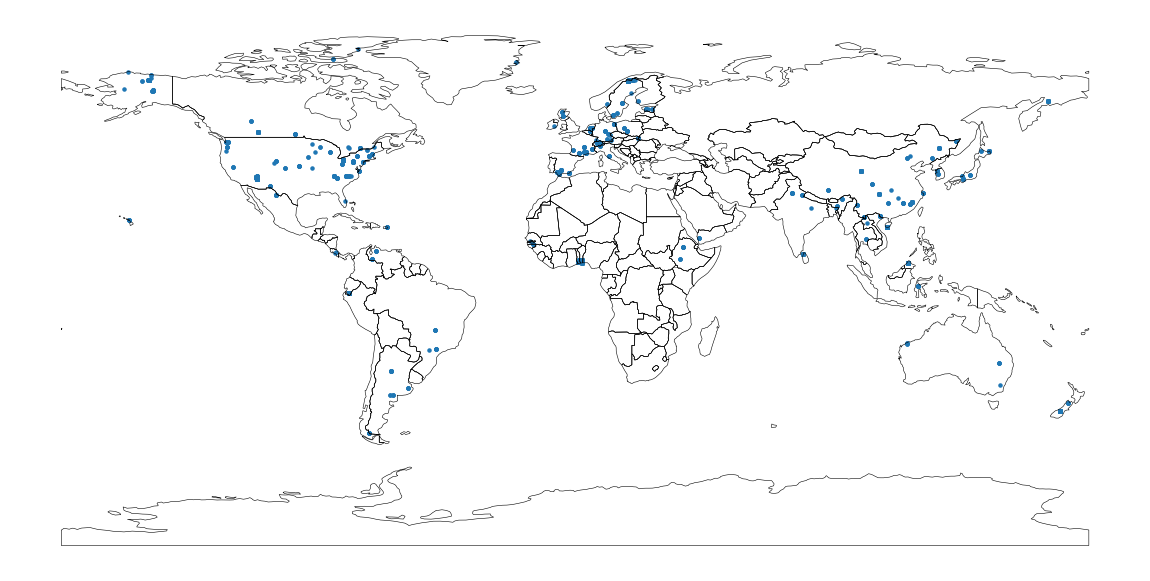

PosixPath('../Data/map_fred.jpg')

In [6]:
# --- Block 5: Basemap (map_units) + FRED points ---

MAP_DIR = Path("../../darkdivnet/Manuscript/Data/Maps/110m_cultural")

MAP_UNITS_FP = MAP_DIR / "ne_110m_admin_0_map_units.shp"
BORDERS_FP   = MAP_DIR / "ne_110m_admin_0_boundary_lines_land.shp"

assert MAP_UNITS_FP.exists(), MAP_UNITS_FP
assert BORDERS_FP.exists(), BORDERS_FP

# Basemap polygons (matches R: ne_countries(type="map_units"))
map_units = gpd.read_file(MAP_UNITS_FP).to_crs("EPSG:4326")

# Optional overlay: boundary linework for sharper borders
borders = gpd.read_file(BORDERS_FP).to_crs("EPSG:4326")

# Coerce FRED coordinates to numeric
fred["lat"] = pd.to_numeric(fred["Latitude_Main"], errors="coerce")
fred["lon"] = pd.to_numeric(fred["Longitude_Main"], errors="coerce")

mask_fred = np.isfinite(fred["lat"].to_numpy()) & np.isfinite(fred["lon"].to_numpy())
fred_xy = fred.loc[mask_fred, ["lat", "lon"]].copy()

print(f"FRED total rows: {len(fred):,}")
print(f"FRED rows with finite Latitude_Main/Longitude_Main: {len(fred_xy):,}")

fred_pts = gpd.GeoDataFrame(
    fred_xy,
    geometry=gpd.points_from_xy(fred_xy["lon"], fred_xy["lat"]),
    crs="EPSG:4326",
)

# Plot
fig, ax = plt.subplots(figsize=(11.81, 5.91))

# Polygons (no fill, just outlines)
map_units.boundary.plot(ax=ax, linewidth=0.4, color="black")

# Optional crisp borders overlay (can comment out if redundant)
borders.plot(ax=ax, linewidth=0.3, color="black")

# Avoid geopandas auto-aspect computation
ax.set_aspect("equal", adjustable="box")

if len(fred_pts) == 0:
    ax.text(
        0.5, 0.5,
        "No FRED points with finite Latitude_Main/Longitude_Main",
        ha="center", va="center",
        transform=ax.transAxes
    )
else:
    fred_pts.plot(ax=ax, markersize=5)

ax.set_axis_off()
plt.tight_layout()

out_map_fred = DATA_DIR / "map_fred.jpg"
# plt.savefig(out_map_fred, dpi=300)
plt.show()

out_map_fred

roots total rows: 2,705
roots rows with finite lat/lon: 2,705


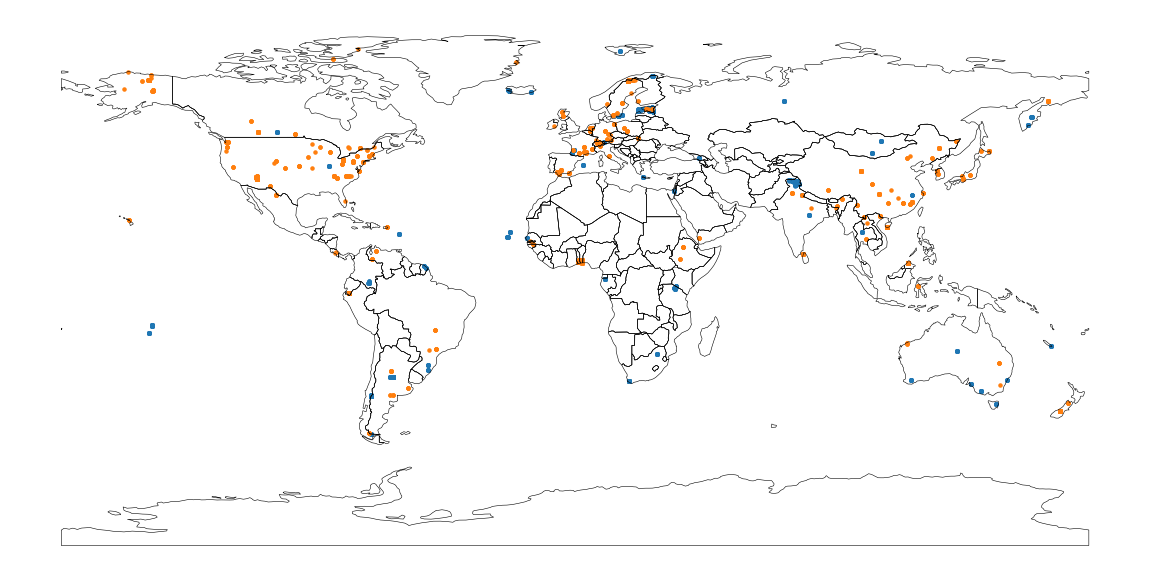

PosixPath('../Data/map_both.jpg')

In [7]:
# --- Block 6: Basemap (map_units) + roots + FRED points ---

# Coerce roots coordinates to numeric
roots["lat"] = pd.to_numeric(roots["lat"], errors="coerce")
roots["lon"] = pd.to_numeric(roots["lon"], errors="coerce")

mask_roots = np.isfinite(roots["lat"].to_numpy()) & np.isfinite(roots["lon"].to_numpy())
roots_xy = roots.loc[mask_roots, ["lat", "lon"]].copy()

print(f"roots total rows: {len(roots):,}")
print(f"roots rows with finite lat/lon: {len(roots_xy):,}")

roots_pts = gpd.GeoDataFrame(
    roots_xy,
    geometry=gpd.points_from_xy(roots_xy["lon"], roots_xy["lat"]),
    crs="EPSG:4326",
)

# Plot
fig, ax = plt.subplots(figsize=(11.81, 5.91))

map_units.boundary.plot(ax=ax, linewidth=0.4, color="black")
borders.plot(ax=ax, linewidth=0.3, color="black")

ax.set_aspect("equal", adjustable="box")

if len(roots_pts) == 0 and len(fred_pts) == 0:
    ax.text(
        0.5, 0.5,
        "No roots or FRED points with finite coordinates",
        ha="center", va="center",
        transform=ax.transAxes
    )
else:
    if len(roots_pts) > 0:
        roots_pts.plot(ax=ax, markersize=5)
    if len(fred_pts) > 0:
        fred_pts.plot(ax=ax, markersize=5)

ax.set_axis_off()
plt.tight_layout()

out_map_both = DATA_DIR / "map_both.jpg"
# plt.savefig(out_map_both, dpi=300)
plt.show()

out_map_both

In [8]:
# --- Block 7: Build robust species names in FRED + overlap with roots ---

# Prefer accepted taxonomy if present; fallback to data-source taxonomy
genus_candidates = [
    "Plant taxonomy_Accepted genus_TPL",
    "Plant taxonomy_Genus_Data Source",
]
species_candidates = [
    "Plant Taxonomy_Accepted species_TPL",
    "Plant taxonomy_Species_Data source",
]

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

genus_col   = first_existing_col(fred, genus_candidates)
species_col = first_existing_col(fred, species_candidates)

print("Using genus column:  ", genus_col)
print("Using species column:", species_col)

# Clean and build binomial name
genus_clean = fred[genus_col].astype(str).str.strip()
species_clean = fred[species_col].astype(str).str.strip()

# Convert common "nan"/"None"/empty strings to NA before concatenation
genus_clean = genus_clean.replace({"nan": np.nan, "None": np.nan, "": np.nan})
species_clean = species_clean.replace({"nan": np.nan, "None": np.nan, "": np.nan})

fred["species"] = (genus_clean + " " + species_clean).str.replace(r"\s+", " ", regex=True).str.strip()

# Drop rows where we couldn't form a species name
fred = fred.loc[fred["species"].notna() & (fred["species"] != "")].copy()

unique_fred  = set(fred["species"].dropna().unique())
unique_roots = set(roots["plant_species"].dropna().astype(str).str.strip().unique())

overlap = sorted(unique_fred.intersection(unique_roots))

print(f"Unique FRED species:  {len(unique_fred):,}")
print(f"Unique roots species: {len(unique_roots):,}")
print(f"Overlap species:      {len(overlap):,}")

Using genus column:   Plant taxonomy_Genus_Data Source
Using species column: Plant taxonomy_Species_Data source
Unique FRED species:  1,002
Unique roots species: 462
Overlap species:      38


In [9]:
# --- Block 8: Filter to overlap + coerce numeric columns in roots_vt ---

fred_roots = fred.loc[fred["species"].isin(overlap)].copy()
roots_vt   = roots.loc[roots["plant_species"].astype(str).str.strip().isin(overlap)].copy()

num_cols = [
    "prop.cult",
    "prop.ancestral",
    "prop.edaphophilic",
    "prop.rhizophilic",
    "spec.ances",
    "spec.edaph",
    "spec.rhizo",
    "richness",
]

for c in num_cols:
    if c in roots_vt.columns:
        roots_vt[c] = pd.to_numeric(roots_vt[c], errors="coerce")

print("fred_roots:", fred_roots.shape)
print("roots_vt:  ", roots_vt.shape)

fred_roots: (482, 66)
roots_vt:   (397, 460)


In [10]:
# --- Block 9: Species-level summaries + trait means merged ---

# VT/roots summaries
richness_vt = (
    roots_vt.groupby("plant_species", dropna=True)
    .agg(
        mean_richness=("richness", "mean"),
        mean_prop_cult=("prop.cult", "mean"),
        mean_prop_ancestral=("prop.ancestral", "mean"),
        mean_prop_edaphophilic=("prop.edaphophilic", "mean"),
        mean_prop_rhizophilic=("prop.rhizophilic", "mean"),
        mean_sp_ancestral=("spec.ances", "mean"),
        mean_sp_rhizophilic=("spec.rhizo", "mean"),
        mean_sp_edaphophilic=("spec.edaph", "mean"),
    )
    .reset_index()
    .rename(columns={"plant_species": "species"})
)

# Trait means from FRED
trait_map = {
    "Specific root length (SRL)": "mean_srl",
    "Root tissue density (RTD)": "mean_rtd",
    "Root diameter": "mean_rd",
    "Root N content": "mean_rnc",
}

trait_dfs = []
for trait_col, out_col in trait_map.items():
    if trait_col in fred_roots.columns:
        fred_roots[trait_col] = pd.to_numeric(fred_roots[trait_col], errors="coerce")
        tmp = (
            fred_roots.groupby("species", dropna=True)[trait_col]
            .mean()
            .rename(out_col)
            .reset_index()
        )
        trait_dfs.append(tmp)

# Merge: keep only species with VT summaries and trait data
df = richness_vt.copy()
for tdf in trait_dfs:
    df = df.merge(tdf, on="species", how="inner")

df = df.sort_values("mean_richness", ascending=False).reset_index(drop=True)

print("Merged df shape:", df.shape)
df.head()

Merged df shape: (38, 12)


,species,mean_richness,mean_prop_cult,mean_prop_ancestral,mean_prop_edaphophilic,mean_prop_rhizophilic,mean_sp_ancestral,mean_sp_rhizophilic,mean_sp_edaphophilic,mean_rtd,mean_rd,mean_rnc
0,Rosmarinus officinalis,50.000000,14.026435,0.094785,0.026836,99.301661,0.814392,93.082187,0.317460,0.534581,0.424333,NaN
1,Agropyron cristatum,39.875000,37.867824,0.071277,0.072312,99.151453,2.037757,92.351198,2.344470,NaN,NaN,4.7
2,Rumex acetosella,36.000000,20.506329,0.000000,0.000000,98.354430,0.000000,100.000000,0.000000,0.243568,NaN,3.9
3,Stipa krylovii,35.000000,41.263001,0.048102,1.373583,98.013592,2.388889,91.328914,4.306503,NaN,NaN,8.1
4,Artemisia frigida,33.583333,37.133090,0.321700,0.042215,98.153817,0.742620,95.728368,0.528888,0.362104,0.247860,NaN


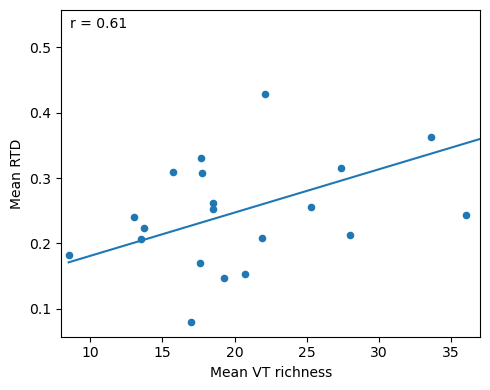

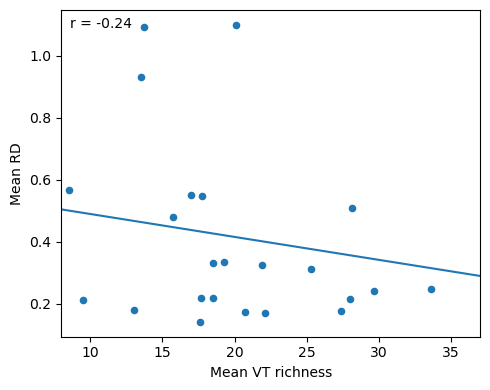

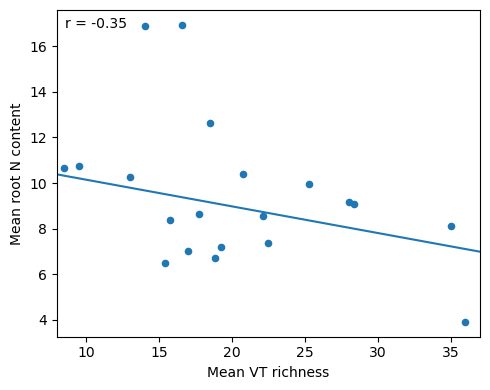

In [12]:
# --- Block 10: Scatter + regression helper + replicate plots ---

from scipy.stats import linregress

def scatter_lm(df, x, y, xlim=None, xlabel=None, ylabel=None, out_fp=None):
    d = df[[x, y]].dropna()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(d[x], d[y], s=20)

    lr = linregress(d[x].values, d[y].values)
    xx = np.linspace(d[x].min(), d[x].max(), 100)
    ax.plot(xx, lr.intercept + lr.slope * xx)

    if xlim is not None:
        ax.set_xlim(xlim)

    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)

    ax.text(
        0.02, 0.98,
        f"r = {lr.rvalue:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
    )

    plt.tight_layout()
    # if out_fp is not None:
        # plt.savefig(out_fp, dpi=300)
    plt.show()

# Plots analogous to the R code
# scatter_lm(df, "mean_richness", "mean_srl", xlim=(8, 37),
           # xlabel="Mean VT richness", ylabel="Mean SRL",
           # out_fp=DATA_DIR/"richness_vs_srl.jpg")

scatter_lm(df, "mean_richness", "mean_rtd", xlim=(8, 37),
           xlabel="Mean VT richness", ylabel="Mean RTD",
           out_fp=DATA_DIR/"richness_vs_rtd.jpg")

scatter_lm(df, "mean_richness", "mean_rd", xlim=(8, 37),
           xlabel="Mean VT richness", ylabel="Mean RD",
           out_fp=DATA_DIR/"richness_vs_rd.jpg")

scatter_lm(df, "mean_richness", "mean_rnc", xlim=(8, 37),
           xlabel="Mean VT richness", ylabel="Mean root N content",
           out_fp=DATA_DIR/"richness_vs_rnc.jpg")

In [13]:
# --- Block: Report matching + non-matching (roots/ecobank vs FRED) genus+species ---

import re

# 1) Helper to split "Genus species" (keeps only first two tokens)
def split_binomial(name: str):
    if pd.isna(name):
        return (np.nan, np.nan)
    s = str(name).strip()
    if not s:
        return (np.nan, np.nan)
    parts = re.split(r"\s+", s)
    genus = parts[0] if len(parts) >= 1 else np.nan
    species = parts[1] if len(parts) >= 2 else np.nan
    return (genus, species)

# 2) Build ROOTS/ecobank binomials from plant_species
roots_species = (
    roots["plant_species"]
    .dropna()
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .drop_duplicates()
)
roots_binom = pd.DataFrame(
    roots_species.apply(split_binomial).tolist(),
    columns=["genus", "species"],
)
roots_binom["binomial"] = roots_binom["genus"].fillna("") + " " + roots_binom["species"].fillna("")
roots_binom["binomial"] = roots_binom["binomial"].str.strip()
roots_binom = roots_binom[(roots_binom["genus"].notna()) & (roots_binom["species"].notna())]

# 3) Build FRED binomials (assumes you already created fred["species"] as "Genus species")
fred_species = (
    fred["species"]
    .dropna()
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .drop_duplicates()
)
fred_binom = pd.DataFrame(
    fred_species.apply(split_binomial).tolist(),
    columns=["genus", "species"],
)
fred_binom["binomial"] = fred_binom["genus"].fillna("") + " " + fred_binom["species"].fillna("")
fred_binom["binomial"] = fred_binom["binomial"].str.strip()
fred_binom = fred_binom[(fred_binom["genus"].notna()) & (fred_binom["species"].notna())]

# 4) Compute sets
roots_set = set(roots_binom["binomial"].unique())
fred_set  = set(fred_binom["binomial"].unique())

match_set      = roots_set & fred_set
roots_only_set = roots_set - fred_set
fred_only_set  = fred_set - roots_set

# 5) Pretty print
def print_list(title, items, n=50):
    items = sorted(items)
    print("\n" + "=" * 80)
    print(f"{title}  (n={len(items):,})")
    print("=" * 80)
    for x in items[:n]:
        print(x)
    if len(items) > n:
        print(f"... ({len(items)-n:,} more)")

print_list("MATCHING binomials (roots/ecobank ∩ FRED)", match_set, n=50)
print_list("ROOTS/ECOBANK-ONLY binomials (roots/ecobank \\ FRED)", roots_only_set, n=50)
print_list("FRED-ONLY binomials (FRED \\ roots/ecobank)", fred_only_set, n=50)

# 6) Optional: genus-level overlap summary
roots_genera = set(roots_binom["genus"].unique())
fred_genera  = set(fred_binom["genus"].unique())

print("\n" + "=" * 80)
print("GENUS overlap summary")
print("=" * 80)
print(f"Roots/ecobank genera: {len(roots_genera):,}")
print(f"FRED genera:          {len(fred_genera):,}")
print(f"Overlap genera:       {len(roots_genera & fred_genera):,}")
print(f"Roots-only genera:    {len(roots_genera - fred_genera):,}")
print(f"FRED-only genera:     {len(fred_genera - roots_genera):,}")


MATCHING binomials (roots/ecobank ∩ FRED)  (n=40)
Acer saccharum
Achillea millefolium
Agropyron cristatum
Agrostis capillaris
Antennaria dioica
Artemisia campestris
Artemisia frigida
Artemisia ludoviciana
Campanula rotundifolia
Carex moorcroftii
Cenchrus ciliaris
Cocos nucifera
Cornus suecica
Dactylis glomerata
Deschampsia cespitosa
Deschampsia flexuosa
Dichanthium annulatum
Festuca ovina
Galium boreale
Geranium sylvaticum
Hedera helix
Helichrysum stoechas
Heterotheca villosa
Juniperus communis
Koeleria macrantha
Lotus corniculatus
Medicago sativa
Phragmites australis
Plantago lanceolata
Podophyllum peltatum
Potentilla neumanniana
Prunella vulgaris
Rosmarinus officinalis
Rubus saxatilis
Rumex acetosella
Ruscus aculeatus
Solidago missouriensis
Stipa comata
Stipa krylovii
Taraxacum officinale

ROOTS/ECOBANK-ONLY binomials (roots/ecobank \ FRED)  (n=420)
Acacia erioloba
Acacia seyal
Acinos arvensis
Aconogonon rumicifolium
Actaea spicata
Actinotus minor
Aegopodium podagraria
Ageratum cony

In [14]:
# --- Block: Find likely misspellings / near-matches between roots/ecobank and FRED (fixed) ---

import re
import difflib

import numpy as np
import pandas as pd

# ----------------------------
# 0) Build clean binomial sets from both datasets (self-contained)
# ----------------------------
def split_binomial(name: str):
    if pd.isna(name):
        return (np.nan, np.nan)
    s = str(name).strip()
    if not s:
        return (np.nan, np.nan)
    parts = re.split(r"\s+", s)
    genus = parts[0] if len(parts) >= 1 else np.nan
    species = parts[1] if len(parts) >= 2 else np.nan
    return (genus, species)

def clean_name_series(s: pd.Series) -> pd.Series:
    s = s.dropna().astype(str)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    # Normalize common artifacts
    s = s.str.replace(r"\u00d7", "x", regex=False)        # hybrid sign
    s = s.str.replace(r"[^\w\s\.-]", "", regex=True)      # drop punctuation except . and -
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s.drop_duplicates()

roots_species = clean_name_series(roots["plant_species"])
fred_species  = clean_name_series(fred["species"])

roots_binom = pd.DataFrame(roots_species.apply(split_binomial).tolist(), columns=["genus", "species"])
fred_binom  = pd.DataFrame(fred_species.apply(split_binomial).tolist(),  columns=["genus", "species"])

# Keep only proper binomials (2 tokens)
roots_binom = roots_binom.dropna().copy()
fred_binom  = fred_binom.dropna().copy()

roots_binom["binomial"] = (roots_binom["genus"] + " " + roots_binom["species"]).str.strip()
fred_binom["binomial"]  = (fred_binom["genus"]  + " " + fred_binom["species"]).str.strip()

roots_set = set(roots_binom["binomial"].unique())
fred_set  = set(fred_binom["binomial"].unique())

roots_only = sorted(roots_set - fred_set)
fred_only  = sorted(fred_set - roots_set)

# ----------------------------
# 1) Similarity backend: RapidFuzz if available, else difflib
# ----------------------------
try:
    from rapidfuzz import fuzz, process
    HAVE_RAPIDFUZZ = True
except Exception:
    HAVE_RAPIDFUZZ = False

def best_match(query, choices):
    """Return (match, score_0_100)."""
    if HAVE_RAPIDFUZZ:
        m = process.extractOne(query, choices, scorer=fuzz.WRatio)
        return (m[0], float(m[1])) if m else (None, 0.0)
    else:
        matches = difflib.get_close_matches(query, choices, n=1, cutoff=0.0)
        if not matches:
            return (None, 0.0)
        score = difflib.SequenceMatcher(None, query, matches[0]).ratio() * 100.0
        return (matches[0], float(score))

# ----------------------------
# 2) Genus-constrained near-matches (fix: handle empty out cleanly)
# ----------------------------
def genus_constrained_pairs(roots_only, fred_only, min_score=90.0, max_pairs=200):
    roots_df = pd.DataFrame([split_binomial(x) for x in roots_only], columns=["genus", "species"])
    roots_df["binomial"] = roots_only
    fred_df = pd.DataFrame([split_binomial(x) for x in fred_only], columns=["genus", "species"])
    fred_df["binomial"] = fred_only

    out = []
    common_genera = sorted(set(roots_df["genus"]) & set(fred_df["genus"]))
    for g in common_genera:
        r_species = roots_df.loc[roots_df["genus"] == g, "species"].dropna().astype(str).unique().tolist()
        f_species = fred_df.loc[fred_df["genus"] == g, "species"].dropna().astype(str).unique().tolist()
        if not r_species or not f_species:
            continue

        if HAVE_RAPIDFUZZ:
            for rs in r_species:
                match = process.extractOne(rs, f_species, scorer=fuzz.WRatio)
                if match and float(match[1]) >= min_score:
                    fs, sc = match[0], float(match[1])
                    out.append({"genus": g, "roots": f"{g} {rs}", "fred": f"{g} {fs}", "score": sc, "method": "genus_constrained"})
        else:
            for rs in r_species:
                ms = difflib.get_close_matches(rs, f_species, n=1, cutoff=0.0)
                if ms:
                    fs = ms[0]
                    sc = difflib.SequenceMatcher(None, rs, fs).ratio() * 100.0
                    if sc >= min_score:
                        out.append({"genus": g, "roots": f"{g} {rs}", "fred": f"{g} {fs}", "score": float(sc), "method": "genus_constrained"})

        if len(out) >= max_pairs:
            break

    if not out:
        # Return an empty df with expected columns so downstream printing/saving is stable
        return pd.DataFrame(columns=["genus", "roots", "fred", "score", "method"])

    return (
        pd.DataFrame(out)
        .sort_values(["score", "genus"], ascending=[False, True])
        .head(max_pairs)
        .reset_index(drop=True)
    )

# ----------------------------
# 3) Global near-match search on full binomial (catches genus typos too)
# ----------------------------
def global_pairs(one_side, other_side, min_score=92.0, max_pairs=200, label_left="left", label_right="right"):
    out = []
    other_choices = list(other_side)
    for q in one_side:
        m, sc = best_match(q, other_choices)
        if m is not None and sc >= min_score:
            out.append({label_left: q, label_right: m, "score": sc, "method": "global_binomial"})
        if len(out) >= max_pairs:
            break

    if not out:
        return pd.DataFrame(columns=[label_left, label_right, "score", "method"])

    return pd.DataFrame(out).sort_values("score", ascending=False).head(max_pairs).reset_index(drop=True)

# ----------------------------
# 4) Run and print
# ----------------------------
MIN_SCORE_GENUS  = 80.0
MIN_SCORE_GLOBAL = 85.0

df_genus = genus_constrained_pairs(roots_only, fred_only, min_score=MIN_SCORE_GENUS, max_pairs=200)
df_r2f   = global_pairs(roots_only, fred_only, min_score=MIN_SCORE_GLOBAL, max_pairs=200, label_left="roots_only", label_right="fred_only_best")
df_f2r   = global_pairs(fred_only, roots_only, min_score=MIN_SCORE_GLOBAL, max_pairs=200, label_left="fred_only", label_right="roots_only_best")

print("\n" + "="*90)
print(f"LIKELY MISSPELLINGS / NEAR-MATCHES (GENUS-CONSTRAINED, score ≥ {MIN_SCORE_GENUS:g})")
print("="*90)
print("None found at this threshold." if df_genus.empty else df_genus.to_string(index=False))

print("\n" + "="*90)
print(f"LIKELY MISSPELLINGS / NEAR-MATCHES (GLOBAL BINOMIAL: roots_only → fred_only, score ≥ {MIN_SCORE_GLOBAL:g})")
print("="*90)
print("None found at this threshold." if df_r2f.empty else df_r2f.to_string(index=False))

print("\n" + "="*90)
print(f"LIKELY MISSPELLINGS / NEAR-MATCHES (GLOBAL BINOMIAL: fred_only → roots_only, score ≥ {MIN_SCORE_GLOBAL:g})")
print("="*90)
print("None found at this threshold." if df_f2r.empty else df_f2r.to_string(index=False))

# ----------------------------
# 5) Save (optional)
# ----------------------------
OUT_FP = Path("../Data/near_match_candidates.csv")

to_save = []

if not df_genus.empty:
    to_save.append(df_genus.rename(columns={"roots": "roots_name", "fred": "fred_name"}))

if not df_r2f.empty:
    to_save.append(df_r2f.rename(columns={"roots_only": "roots_name", "fred_only_best": "fred_name"}))

if not df_f2r.empty:
    to_save.append(df_f2r.rename(columns={"fred_only": "fred_name", "roots_only_best": "roots_name"}))

if to_save:
    pd.concat(to_save, ignore_index=True).drop_duplicates().to_csv(OUT_FP, index=False)
    print(f"\nSaved candidate near-matches to: {OUT_FP}")
else:
    print("\nNo candidates found; nothing saved.")


LIKELY MISSPELLINGS / NEAR-MATCHES (GENUS-CONSTRAINED, score ≥ 80)
None found at this threshold.

LIKELY MISSPELLINGS / NEAR-MATCHES (GLOBAL BINOMIAL: roots_only → fred_only, score ≥ 85)
            roots_only          fred_only_best     score          method
      Linnaea borealis         Linnea borealis 96.774194 global_binomial
 Dichrostachys cinerea Dichronostachys cinerea 95.454545 global_binomial
  Hypochoeris radicata    Hypochaeris radicata 95.000000 global_binomial
       Cirsium arvense       Cerastium arvense 87.500000 global_binomial
  Filipendula vulgaris     Filipendula ulmaria 87.179487 global_binomial
Helianthemum viscarium      Helianthemum canum 85.000000 global_binomial

LIKELY MISSPELLINGS / NEAR-MATCHES (GLOBAL BINOMIAL: fred_only → roots_only, score ≥ 85)
              fred_only        roots_only_best     score          method
        Linnea borealis       Linnaea borealis 96.774194 global_binomial
Dichronostachys cinerea  Dichrostachys cinerea 95.454545 global_b

In [15]:
# --- Block: Near-miss detection using canonicalized binomials (fixed for empty results) ---

import re
import difflib
import numpy as np
import pandas as pd
from pathlib import Path

# Optional faster/better fuzzy matching if installed
try:
    from rapidfuzz import fuzz, process
    HAVE_RAPIDFUZZ = True
except Exception:
    HAVE_RAPIDFUZZ = False

# ----------------------------
# 1) Canonicalize plant names to "Genus epithet"
# ----------------------------
QUALIFIERS = {
    "sp", "sp.", "spp", "spp.", "indet", "indet.", "cf", "cf.", "aff", "aff.",
    "nr", "nr.", "unidentified", "unknown"
}
INFRA = {"subsp", "subsp.", "ssp", "ssp.", "var", "var.", "forma", "forma.", "f", "f."}

def canonical_binomial(name: str):
    if pd.isna(name):
        return (np.nan, np.nan, np.nan)

    s = str(name).strip()
    if not s:
        return (np.nan, np.nan, np.nan)

    # Remove parenthetical authorship and normalize
    s = re.sub(r"\([^)]*\)", " ", s)
    s = s.replace("×", "x")
    s = re.sub(r"[^\w\s-]", " ", s)   # keep hyphens
    s = re.sub(r"\s+", " ", s).strip()

    parts = s.split(" ")
    if len(parts) < 2:
        return (np.nan, np.nan, np.nan)

    genus = parts[0]
    epithet = None

    for tok in parts[1:]:
        t = tok.lower().strip()

        if t in INFRA or t in QUALIFIERS:
            continue
        if len(t) == 1:
            continue
        if re.fullmatch(r"[a-z]+(-[a-z]+)?", t) is None:
            continue

        epithet = t
        break

    if epithet is None:
        return (np.nan, np.nan, np.nan)

    canon = f"{genus} {epithet}"
    return (canon, genus, epithet)

def build_name_table(series: pd.Series, source_label: str) -> pd.DataFrame:
    s = (
        series.dropna()
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .drop_duplicates()
    )
    rows = [canonical_binomial(x) for x in s.tolist()]
    df = pd.DataFrame(rows, columns=["canon", "genus", "epithet"])
    df["raw"] = s.values
    df["source"] = source_label
    df = df.dropna(subset=["canon"]).drop_duplicates(subset=["canon", "raw"])
    return df

roots_tbl = build_name_table(roots["plant_species"], "roots/ecobank")
fred_tbl  = build_name_table(fred["species"], "FRED")

roots_canon = set(roots_tbl["canon"].unique())
fred_canon  = set(fred_tbl["canon"].unique())

roots_only_canon = sorted(roots_canon - fred_canon)
fred_only_canon  = sorted(fred_canon - roots_canon)

print(f"Canonical roots-only: {len(roots_only_canon):,}")
print(f"Canonical FRED-only:  {len(fred_only_canon):,}")

# ----------------------------
# 2) Fuzzy matching helpers
# ----------------------------
def best_match(query, choices):
    if HAVE_RAPIDFUZZ:
        m = process.extractOne(query, choices, scorer=fuzz.WRatio)
        return (m[0], float(m[1])) if m else (None, 0.0)
    else:
        matches = difflib.get_close_matches(query, choices, n=1, cutoff=0.0)
        if not matches:
            return (None, 0.0)
        sc = difflib.SequenceMatcher(None, query, matches[0]).ratio() * 100.0
        return (matches[0], float(sc))

def get_raw_examples(tbl: pd.DataFrame, canon: str, n=3):
    ex = tbl.loc[tbl["canon"] == canon, "raw"].head(n).tolist()
    return "; ".join(ex)

# ----------------------------
# 3) Genus-constrained near-matches among canonical names
# ----------------------------
MIN_SCORE_GENUS  = 80.0   # set low for exploration
MIN_SCORE_GLOBAL = 85.0

fred_by_genus = {
    g: sorted(fred_tbl.loc[fred_tbl["genus"] == g, "canon"].unique())
    for g in fred_tbl["genus"].dropna().unique()
}

genus_hits = []
for q in roots_only_canon:
    q_genus = q.split(" ", 1)[0]
    choices = fred_by_genus.get(q_genus, [])
    if not choices:
        continue
    m, sc = best_match(q, choices)
    if m and sc >= MIN_SCORE_GENUS:
        genus_hits.append({
            "roots_canon": q,
            "fred_canon": m,
            "score": sc,
            "roots_raw_examples": get_raw_examples(roots_tbl, q),
            "fred_raw_examples": get_raw_examples(fred_tbl, m),
            "method": "genus_constrained_canonical",
        })

# FIX: handle empty list before sorting
if genus_hits:
    df_genus = (
        pd.DataFrame(genus_hits)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
else:
    df_genus = pd.DataFrame(columns=["roots_canon","fred_canon","score","roots_raw_examples","fred_raw_examples","method"])

# ----------------------------
# 4) Global near-matches among canonical names (roots_only_canon -> fred_only_canon)
# ----------------------------
global_hits = []
fred_choices = fred_only_canon[:]  # compare only among canonical non-overlaps

for q in roots_only_canon:
    m, sc = best_match(q, fred_choices)
    if m and sc >= MIN_SCORE_GLOBAL:
        global_hits.append({
            "roots_canon": q,
            "fred_canon": m,
            "score": sc,
            "roots_raw_examples": get_raw_examples(roots_tbl, q),
            "fred_raw_examples": get_raw_examples(fred_tbl, m),
            "method": "global_canonical",
        })

if global_hits:
    df_global = (
        pd.DataFrame(global_hits)
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
else:
    df_global = pd.DataFrame(columns=["roots_canon","fred_canon","score","roots_raw_examples","fred_raw_examples","method"])

# ----------------------------
# 5) Print results
# ----------------------------
print("\n" + "="*110)
print(f"GENUS-CONSTRAINED NEAR-MATCHES (canonical), score ≥ {MIN_SCORE_GENUS:g}")
print("="*110)
print("None found." if df_genus.empty else df_genus.head(50).to_string(index=False))

print("\n" + "="*110)
print(f"GLOBAL NEAR-MATCHES (canonical), score ≥ {MIN_SCORE_GLOBAL:g}")
print("="*110)
print("None found." if df_global.empty else df_global.head(50).to_string(index=False))

# ----------------------------
# 6) Optional: save
# ----------------------------
OUT_FP = Path("../Data/near_match_candidates_canonical.csv")
df_out = pd.concat([df_genus, df_global], ignore_index=True).drop_duplicates()

if not df_out.empty:
    df_out.to_csv(OUT_FP, index=False)
    print(f"\nSaved: {OUT_FP}")
else:
    print("\nNo near-match candidates found (even after canonicalization).")

Canonical roots-only: 396
Canonical FRED-only:  883

GENUS-CONSTRAINED NEAR-MATCHES (canonical), score ≥ 80
            roots_canon              fred_canon     score      roots_raw_examples       fred_raw_examples                      method
 Deschampsia caespitosa   Deschampsia cespitosa 97.674419  Deschampsia caespitosa   Deschampsia cespitosa genus_constrained_canonical
   Filipendula vulgaris     Filipendula ulmaria 87.179487    Filipendula vulgaris     Filipendula ulmaria genus_constrained_canonical
    Artemisia rupestris    Artemisia campestris 87.179487     Artemisia rupestris    Artemisia campestris genus_constrained_canonical
 Helianthemum viscarium      Helianthemum canum 85.000000  Helianthemum viscarium      Helianthemum canum genus_constrained_canonical
 Artemisia macrocephala Artemisia codonocephala 84.444444  Artemisia macrocephala Artemisia codonocephala genus_constrained_canonical
   Potentilla curviseta      Potentilla crinita 84.210526    Potentilla curviseta      P

In [34]:
# how many 'sp.' / qualifiers are in roots-only vs fred-only?
pd.Series([x.split(" ",1)[1] if " " in x else "" for x in roots_only]).value_counts().head(20)
pd.Series([x.split(" ",1)[1] if " " in x else "" for x in fred_only]).value_counts().head(20)

vulgaris          4
alpina            2
europaea          2
grandis           2
vulgare           2
officinalis       2
pseudoplatanus    1
cytisoides        1
gerardii          1
elatius           1
terniflora        1
glutinosa         1
incana            1
falcatus          1
scabra            1
erectus           1
pinnatum          1
bituminosa        1
tridentata        1
korshinskii       1
Name: count, dtype: int64

In [36]:
# --- Block: Keep only "likely misspellings" (not just nearest neighbor) + safe concat (no FutureWarning) ---
import os
import re
import difflib
import numpy as np
import pandas as pd
from pathlib import Path

def norm_for_compare(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def epithet(s: str) -> str:
    # expects "Genus epithet"
    parts = str(s).split(" ", 1)
    return parts[1].strip().lower() if len(parts) == 2 else ""

def is_likely_misspelling(a: str, b: str, max_edit=2, min_prefix=5) -> bool:
    """
    Heuristic:
      - same genus required (caller should ensure)
      - epithet differs by small edit distance OR shares long prefix
    """
    ea, eb = epithet(a), epithet(b)
    if not ea or not eb or ea == eb:
        return False

    # edit distance via SequenceMatcher "opcodes" (approx)
    # Convert similarity to an estimated edit distance bound:
    sm = difflib.SequenceMatcher(None, ea, eb)
    ratio = sm.ratio()
    # crude upper bound: edits <= max_edit tends to give high ratio; we also allow long shared prefix
    common_prefix = len(os.path.commonprefix([ea, eb])) if "os" in globals() else len(re.match(r"^([a-z]+)", ea).group(1)) if False else len(os.path.commonprefix([ea, eb]))

    # quick exact Levenshtein if rapidfuzz is available
    try:
        from rapidfuzz.distance import Levenshtein
        ed = Levenshtein.distance(ea, eb)
    except Exception:
        # fallback: approximate edit distance from ratio (rough)
        ed = int(round((1 - ratio) * max(len(ea), len(eb))))

    return (ed <= max_edit) or (common_prefix >= min_prefix)

# 1) Load previously saved candidate file (from your earlier block)
IN_FP = Path("../Data/near_match_candidates_canonical.csv")
assert IN_FP.exists(), IN_FP
cand = pd.read_csv(IN_FP)

# 2) Keep only genus-constrained rows (those are interpretable)
cand = cand.loc[cand["method"].eq("genus_constrained_canonical")].copy()

# 3) Require same genus explicitly + apply misspelling heuristic
cand["roots_genus"] = cand["roots_canon"].astype(str).str.split(" ", n=1).str[0]
cand["fred_genus"]  = cand["fred_canon"].astype(str).str.split(" ", n=1).str[0]
cand = cand.loc[cand["roots_genus"].eq(cand["fred_genus"])].copy()

cand["likely_misspelling"] = [
    is_likely_misspelling(r, f, max_edit=2, min_prefix=6)
    for r, f in zip(cand["roots_canon"], cand["fred_canon"])
]

cand_miss = cand.loc[cand["likely_misspelling"]].copy()

print("\n" + "="*110)
print("LIKELY MISSPELLINGS (same genus; small edit distance / long shared prefix)")
print("="*110)
if cand_miss.empty:
    print("None detected under this heuristic. (Differences are likely true taxonomic non-overlap.)")
else:
    print(cand_miss[["roots_canon","fred_canon","score","roots_raw_examples","fred_raw_examples"]].to_string(index=False))

# 4) Save filtered list
OUT_FP = Path("../Data/likely_misspellings_only.csv")
cand_miss.to_csv(OUT_FP, index=False)
print(f"\nSaved: {OUT_FP}")


LIKELY MISSPELLINGS (same genus; small edit distance / long shared prefix)
None detected under this heuristic. (Differences are likely true taxonomic non-overlap.)

Saved: ../Data/likely_misspellings_only.csv
